# Dataset Submission Review

This notebook is a suggested workflow for reviewing dataset submissions to the Open Reaction Database public repository.

## 1. Loading the dataset

In [171]:
# Import modules
import ord_schema
from ord_schema import message_helpers, validations
from ord_schema.proto import dataset_pb2
from ord_schema.proto import reaction_pb2

import numpy as np
import random


In [2]:
# Load Dataset message
pb = "./attempts_dataset.pbtxt"
data = message_helpers.load_message(pb, dataset_pb2.Dataset)

## 2. Count reactions and run automated validations

**Review Importance:** Essential Check. This check should be performed for all dataset reviews.

**Methodology:** We count the reactions in the dataset, and also use the automated validations tools in ord-schema to check for common errors and warnings.

In [9]:
# count the reactions

print(len(data.reactions))

44


In [16]:
# run automated validations on the dataset
valid_output = validations.validate_message(data)
print(f"There are {len(valid_output.errors)} errors, and {len(valid_output.warnings)} warnings")

There are 0 errors, and 88 warnings


In [22]:
# print out any errors
for error in valid_output.errors:
    print(error)

In [23]:
# print out any warnings
for warning in valid_output.warnings:
    print(warning)

Dataset.reactions[0].outcomes[0].products[0].measurements[0]: Product measurements should be associated with an analysis through its analysis_key
Dataset.reactions[0].outcomes[0].products[0].measurements[0]: YIELD measurements should be defined as percentage values if possible
Dataset.reactions[1].outcomes[0].products[0].measurements[0]: Product measurements should be associated with an analysis through its analysis_key
Dataset.reactions[1].outcomes[0].products[0].measurements[0]: YIELD measurements should be defined as percentage values if possible
Dataset.reactions[2].outcomes[0].products[0].measurements[0]: Product measurements should be associated with an analysis through its analysis_key
Dataset.reactions[2].outcomes[0].products[0].measurements[0]: YIELD measurements should be defined as percentage values if possible
Dataset.reactions[3].outcomes[0].products[0].measurements[0]: Product measurements should be associated with an analysis through its analysis_key
Dataset.reactions[3]

### Comments

- It looks like it is the same two warnings in each reaction, so we should just check it in a single reaction.
- "YIELD measurements should be defined as percentage values if possible" - check why the yields aren't percentages
- "Product measurements should be associated with an analysis through its analysis_key" - each measurement point should have an associated analysis message. It looks like they could have been left out in this dataset.

## 3. Check the dataset name and description

**Review Importance:** Essential Check. This check should be performed for all dataset reviews.

**Methodology:** We are checking that the name and description are appropriate for the public ORD database.

In [36]:
# check the dataset name
print(data.name)

attempts_dataset


In [37]:
# check the dataset description
print(data.description)

Enumerated by the ORD web interface.


### Inspect the dataset structure and compare to description

In [42]:
# extract the non-constant variables and turn them into a DataFrame
df = message_helpers.messages_to_dataframe(data.reactions, drop_constant_columns=True)

# view dataframe
#df

In [53]:
# DataFrame.info() will give a quick overview of the dataset, the column types, and reveal if there are any null values in columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 20 columns):
 #   Column                                                                                            Non-Null Count  Dtype  
---  ------                                                                                            --------------  -----  
 0   inputs["Input 1"].components[0].identifiers[0].value                                              44 non-null     object 
 1   inputs["Input 1"].components[0].amount.moles.value                                                44 non-null     float64
 2   inputs["Input 1"].components[1].identifiers[0].value                                              44 non-null     object 
 3   inputs["Input 1"].components[1].amount.moles.value                                                44 non-null     float64
 4   inputs["Input 1"].components[2].identifiers[0].value                                              44 non-null     object 
 5   inp

For a more detailed review of the dataset structure refer to section 5 of this workflow.

### Name and description checklist

Test the dataset name against the following criteria.

| # | Test Criteria | Pass/Fail | Comment |
|:--|:-------------------------------|:-------|:-------------------|
|1|dataset has a name|pass| NA |
|2|name is sufficiently unique |fail |placeholder name was used  |
|3|name describes the dataset in a few words |fail |placeholder name was used  |
|4|name does not contain any offensive or inappropriate terms |pass |NA  |

Test the dataset description against the following criteria.

| # | Test Criteria | Pass/Fail | Comment |
|:--|:-------------------------------|:-------|:-------------------|
|1|description present|pass| NA |
|2|reaction class(es) is described |fail |placeholder was used  |
|3|dataset structure is described|fail |placeholder was used  |
|4|any special features of the reaction methodology are described|fail |placeholder was used  |
|5|reaction provenance is described|fail |placeholder was used  |
|6|description does not contain any offensive or inappropriate terms |pass |NA  |

### Tips for preparing a good dataset description

The dataset description should provide an immediate snapshot of what is included in the dataset. It should be descriptive enough, that a future user can make a quick assessment of the datasets suitability for machine-learning and other analysis workflows.

Consider if any of the following could be included in your dataset description:
- A short description of the reaction or reaction class being studied.
- The structure of the dataset. Is it full-factorial, a substrate-scope table, an optimisation study, a kinetic study etc. For structured datasets, consider listing the variables with the number of levels tested for each (e.g. 8 bases x 12 ligands).
- If the reactions were performed using specialised equipment (e.g. flow chemistry, photochemistry, automated batch) then this could be described as well.
- If there are particular papers associated with the whole dataset, then these should be given in the description with a DOI.

### Comments

- The dataset name should be more specific.
- The dataset description is an automated statement from ORD web interface. Please replace with an informative description. Consider the following for the description:
    - A short description of the reaction or reaction class being studied.
    - The structure of the dataset. Is it full-factorial, a substrate-scope table, an optimisation study, a kinetic study etc. For structured datasets, consider listing the variables with the number of levels tested for each (e.g. 8 bases x 12 ligands).
    - If the reactions were performed using specialised equipment (e.g. flow chemistry, photochemistry, automated batch) then this could be described as well.
    - If there are particular papers associated with the whole dataset, then these should be given in the description with a DOI.

## 4. Inspect a single reaction

**Review Importance:** Essential Check. This check should be performed for all dataset reviews.

**Methodology:** There are two options for how to check a single reaction.

- Inspect the protocol buffer message for a single reaction in this notebook.
- OR Upload the dataset to https://app.open-reaction-database.org/ and use the graphical interface to inspect a reaction record.

In [34]:
# select a random reaction for inspection
random.seed(123)
random_index = random.randint(0, len(data.reactions))
print(f"We will check the reaction at index={random_index}.")


We will check the reaction at index=3.


In [35]:
# inspect the selected reaction protocol buffer message
print(data.reactions[random_index])

inputs {
  key: "Input 1"
  value {
    components {
      identifiers {
        type: SMILES
        value: "CCCCC(CC)COc1c2cc(-c3cccc([B-]45OC(=O)C[N+]4(C)CC(=O)O5)c3)sc2c(OCC(CC)CCCC)c2ccsc12"
      }
      amount {
        moles {
          value: 0.3
          units: MILLIMOLE
        }
      }
      reaction_role: REACTANT
    }
    components {
      identifiers {
        type: SMILES
        value: "Brc1cc(OCc2ccccc2)cc(OCc2ccccc2)c1"
      }
      amount {
        moles {
          value: 0.1
          units: MILLIMOLE
        }
      }
      reaction_role: REACTANT
    }
    components {
      identifiers {
        type: NAME
        value: "TMSOK"
      }
      identifiers {
        type: SMILES
        value: "C[Si](C)(C)[O-].[K+]"
      }
      amount {
        moles {
          value: 1
          units: MILLIMOLE
        }
      }
      reaction_role: REAGENT
    }
    components {
      identifiers {
        type: NAME
        value: "Pd P(tBu)3 G4"
      }
      identif

### Comments

- product measurement has type=YIELD but has a mass amount. Consider changing the measurement type to AMOUNT if the measurement is really a yield.
- product measurement should be associated with an analysis. Consider adding an analysis of type=WEIGHT and then refer to this key in the product mass measurement
- "Reaction Note / Purification / Characterization" feature should be split into 3 separate messages.
    - "Reaction Note" would go in as a note.
    - "Purification" should go in as a workup (CUSTOM type with the message saved in the details field).
    - "Characterization" could be analytical data associated with the appropriate analysis message (at the outcome.analysis level). 

## 5. Check the dataset structure

**Review Importance:** Optional Check. These checks are useful for reviewing full factorial and HTE datasets.

**Methodology:** We use exploratory data analysis to graphically chart the factors/variables in the dataset.

In [91]:
# import additional packages
import re
import matplotlib.pyplot as plt

### Value Counts

In [58]:
# for each column we can get the value_counts. For factorial datasets this will reveal the number of levels in each variable/factor.
for col in df.columns:
    print(df[col].value_counts())

inputs["Input 1"].components[0].identifiers[0].value
C[N+]12CC(=O)O[B-]1(c1ccc(-c3ccc(-c4cccs4)s3)cc1)OC(=O)C2                                                6
CCCCC(CC)COc1c2cc(-c3ccc4oc([B-]56OC(=O)C(C)(C)[N+]5(C)C(C)(C)C(=O)O6)cc4c3)sc2c(OCC(CC)CCCC)c2ccsc12    6
CC1(C)C(=O)O[B-]2(c3cc4sc(-c5ccc(-c6cccs6)s5)cc4s3)OC(=O)C(C)(C)[N+]21C                                  4
CCCCC(CC)COc1c2cc(-c3cccc([B-]45OC(=O)C[N+]4(C)CC(=O)O5)c3)sc2c(OCC(CC)CCCC)c2ccsc12                     3
C[N+]12CC(=O)O[B-]1(c1cccc(-c3cccs3)c1)OC(=O)C2                                                          2
C[N+]12CC(=O)O[B-]1(c1ccc(-c3ccc(-c4cccs4)s3)s1)OC(=O)C2                                                 2
CC1(C)OB(c2ccc(-c3cccs3)s2)OC1(C)C                                                                       2
CCCCC(CC)COc1c2cc(B3OC(C)(C)C(C)(C)O3)sc2c(OCC(CC)CCCC)c2ccsc12                                          2
CC1(C)OB(c2cccs2)OC1(C)C                                                                   

### Map the columns

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 20 columns):
 #   Column                                                                                            Non-Null Count  Dtype  
---  ------                                                                                            --------------  -----  
 0   inputs["Input 1"].components[0].identifiers[0].value                                              44 non-null     object 
 1   inputs["Input 1"].components[0].amount.moles.value                                                44 non-null     float64
 2   inputs["Input 1"].components[1].identifiers[0].value                                              44 non-null     object 
 3   inputs["Input 1"].components[1].amount.moles.value                                                44 non-null     float64
 4   inputs["Input 1"].components[2].identifiers[0].value                                              44 non-null     object 
 5   inp

In [99]:
# use DataFrame.describe() to check summary stats of any numeric columns
df.describe()

,"inputs[""Input 1""].components[0].amount.moles.value","inputs[""Input 1""].components[1].amount.moles.value","inputs[""Input 1""].components[2].amount.moles.value","inputs[""Input 1""].components[3].amount.moles.value","inputs[""Input 1""].components[4].amount.volume.value",conditions.temperature.setpoint.value,outcomes[0].reaction_time.value,outcomes[0].products[0].measurements[0].amount.mass.value
count,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000
mean,0.325050,0.148386,1.045455,0.012045,7.909091,82.840909,7.750000,18.854773
std,0.424171,0.108282,0.301511,0.013568,0.603023,21.496288,5.417993,18.643495
min,0.067200,0.056000,1.000000,0.010000,4.000000,25.000000,1.000000,1.000000
25%,0.300000,0.100000,1.000000,0.010000,8.000000,60.000000,1.000000,5.425000
50%,0.300000,0.100000,1.000000,0.010000,8.000000,100.000000,12.000000,12.450000
75%,0.300000,0.100000,1.000000,0.010000,8.000000,100.000000,12.000000,27.200000
max,3.000000,0.600000,3.000000,0.100000,8.000000,100.000000,12.000000,80.000000


In [84]:
measurements = []
components = []

for col in df.columns:
    if re.search("measurements*.*value", str(col)):
        measurements.append(str(col))
    if re.search("components*.*identifiers*.*value", str(col)):
        components.append(str(col))


In [105]:
continuous = df.select_dtypes(include= 'float')

### Plot the measurement values

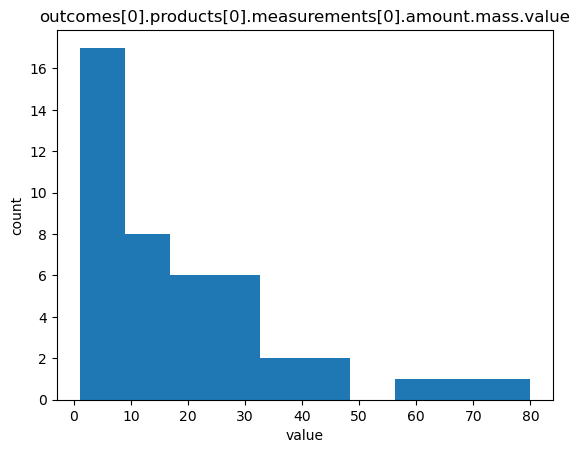

In [98]:
for measurement in measurements:
    series = df[measurement]
    
    plt.hist(series, bins = 10)
    plt.title(measurement)
    plt.xlabel("value")
    plt.ylabel("count")
    plt.show()

### Plot the continuous columns

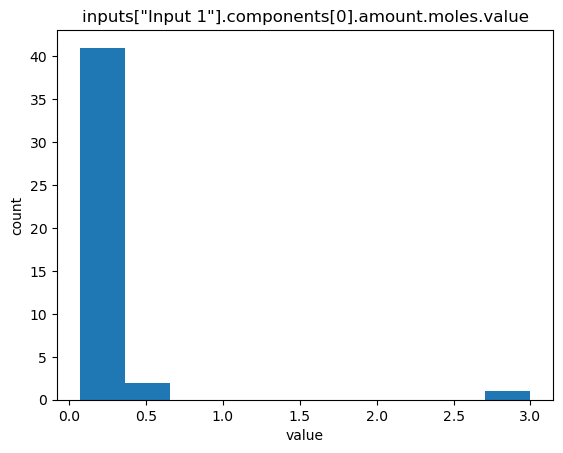

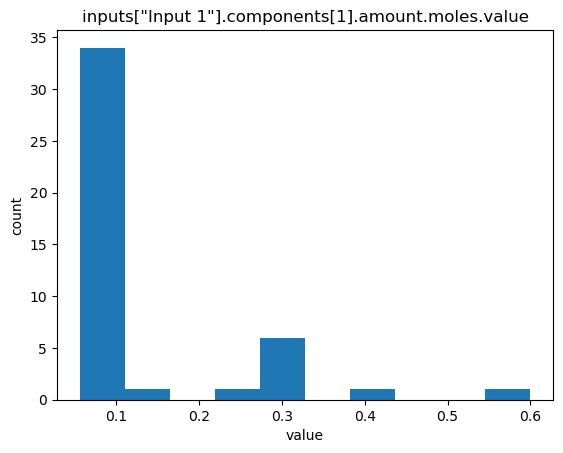

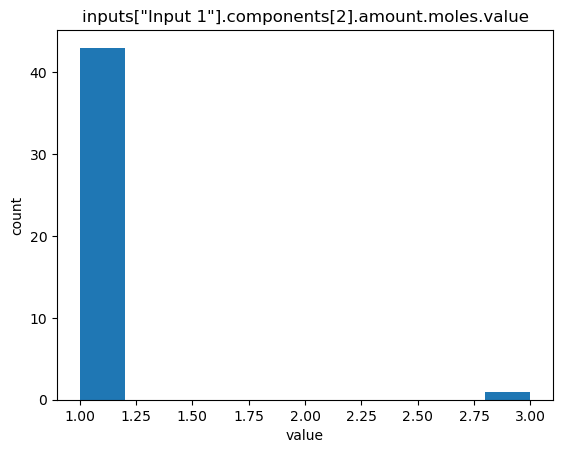

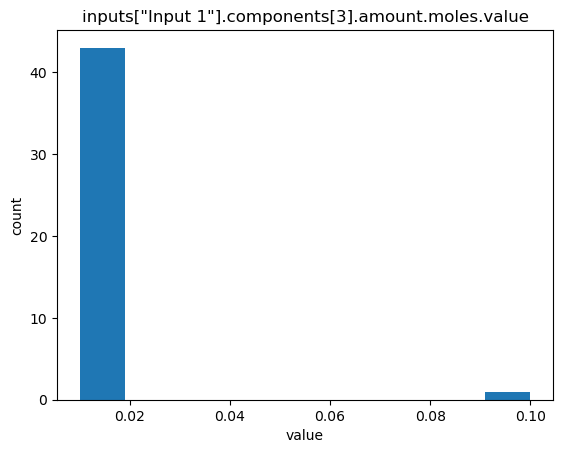

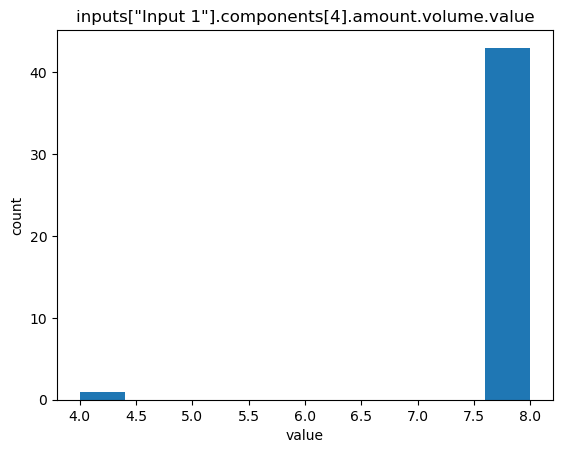

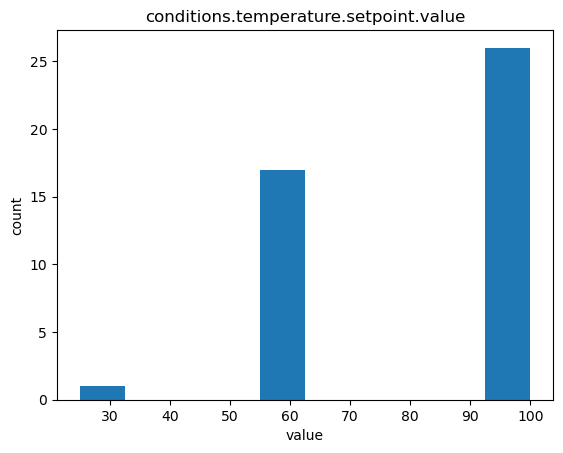

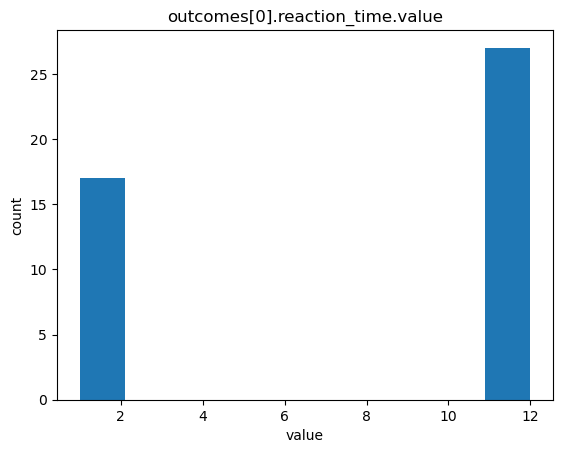

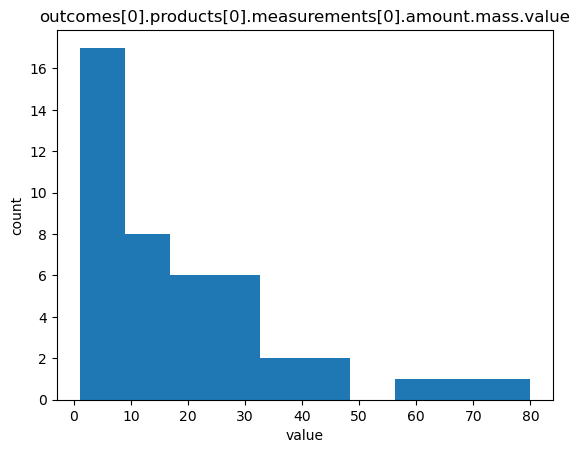

In [110]:
for col in continuous.columns:
    series = continuous[col]
    
    plt.hist(series, bins = 10)
    plt.title(col)
    plt.xlabel("value")
    plt.ylabel("count")
    plt.show()

## 6. Check the chemicals

**Review Importance:** Optional Check. These checks are useful for reviewing full factorial and HTE datasets.

**Methodology:** We use rdkit to visualise the smiles strings

In [237]:
# import additional packages
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole

import pandas as pd

from ord_schema.proto.reaction_pb2 import CompoundIdentifier

In [257]:
#data.ListFields()
#reaction_pb2.CompoundIdentifier.Message
message_helpers.message_to_row(data.reactions[0].inputs["Input 1"].components[0].identifiers[0])
#reaction_pb2.CompoundIdentifier.enum_type.values_by_number[2].name

{'type': 'SMILES', 'value': 'CC1(C)OB(c2cccs2)OC1(C)C'}

In [258]:
message_helpers.messages_to_dataframe(compound_messages)

,identifiers[0].type,identifiers[0].value,amount.moles.value,amount.moles.units,reaction_role,identifiers[1].type,identifiers[1].value,amount.volume.value,amount.volume.units
0,SMILES,CC1(C)OB(c2cccs2)OC1(C)C,0.480,MILLIMOLE,REACTANT,NaN,NaN,NaN,NaN
1,SMILES,O=C(O)c1cc([N+](=O)[O-])cc([N+](=O)[O-])c1Br,0.397,MILLIMOLE,REACTANT,NaN,NaN,NaN,NaN
2,NAME,Na2CO3,1.000,MILLIMOLE,REAGENT,SMILES,O=C([O-])[O-].[Na+].[Na+],NaN,NaN
3,NAME,Pd XPhos G4,0.010,MILLIMOLE,CATALYST,CAS_NUMBER,1599466-81-5,NaN,NaN
4,NAME,5:1 dioxane:water,NaN,NaN,SOLVENT,SMILES,O1CCOCC1.O,8.0,MILLILITER
...,...,...,...,...,...,...,...,...,...
215,SMILES,CC1(C)OB(c2ccc(-c3cccs3)s2)OC1(C)C,0.100,MILLIMOLE,REACTANT,NaN,NaN,NaN,NaN
216,SMILES,CC(C)(C)OC(=O)CN1C(=O)CCc2cc(Br)ccc21,0.100,MILLIMOLE,REACTANT,NaN,NaN,NaN,NaN
217,NAME,Na2CO3,1.000,MILLIMOLE,REAGENT,SMILES,O=C([O-])[O-].[Na+].[Na+],NaN,NaN
218,NAME,Pd XPhos G4,0.010,MILLIMOLE,CATALYST,CAS_NUMBER,1599466-81-5,NaN,NaN


In [173]:
# extract all compound messages from the dataset
compound_messages = message_helpers.find_submessages(message= data, submessage_type= reaction_pb2.Compound)
print(len(compound_messages))

220


In [245]:
# iterate through the compounds and convert to a dataframe
compounds_df = pd.DataFrame()
for compound in compound_messages:
    #print(compound)
    for identifier in compound.identifiers:
        print(identifier.type.label)
        print(identifier.value)
    

AttributeError: 'int' object has no attribute 'label'

[00:43:00] SMILES Parse Error: syntax error while parsing: Na2CO3
[00:43:00] SMILES Parse Error: Failed parsing SMILES 'Na2CO3' for input: 'Na2CO3'
[00:43:00] SMILES Parse Error: syntax error while parsing: TMSOK
[00:43:00] SMILES Parse Error: Failed parsing SMILES 'TMSOK' for input: 'TMSOK'
[00:43:00] SMILES Parse Error: syntax error while parsing: K3PO4
[00:43:00] SMILES Parse Error: Failed parsing SMILES 'K3PO4' for input: 'K3PO4'
[00:43:00] SMILES Parse Error: syntax error while parsing: Pd
[00:43:00] SMILES Parse Error: Failed parsing SMILES 'Pd' for input: 'Pd'
[00:43:00] SMILES Parse Error: syntax error while parsing: Pd
[00:43:00] SMILES Parse Error: Failed parsing SMILES 'Pd' for input: 'Pd'
[00:43:00] SMILES Parse Error: syntax error while parsing: Pd
[00:43:00] SMILES Parse Error: Failed parsing SMILES 'Pd' for input: 'Pd'
[00:43:00] SMILES Parse Error: syntax error while parsing: 1599466-81-5
[00:43:00] SMILES Parse Error: Failed parsing SMILES '1599466-81-5' for input: '15

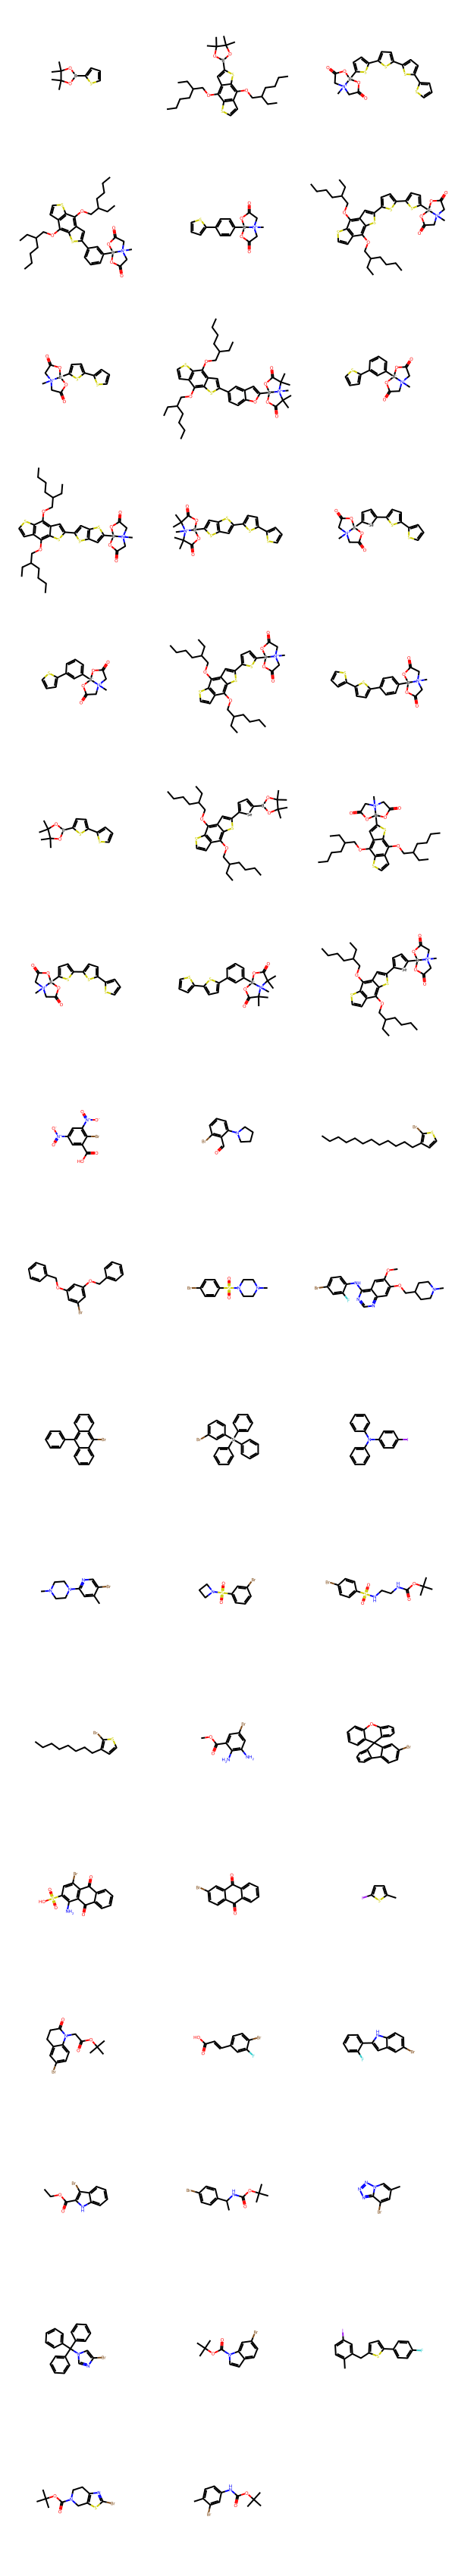

In [141]:
mols = []
for component in components:
    unique_values = df[component].unique()
    
    for chem in unique_values:
        smiles = chem
        #print(smiles)
        m = Chem.MolFromSmiles(smiles)
        mols.append(m)
Draw.MolsToGridImage(mols)

In [122]:
for chem in df[components[0]]:
    m = Chem.MolFromSmiles(chem)
    img = Draw.MolToImage(m)

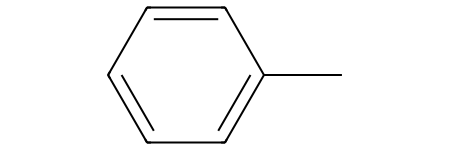

In [126]:
m = Chem.MolFromSmiles('Cc1ccccc1')
m
#img = Draw.MolToImage(m)
#img.show()